In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
'''plt.style.use("seaborn")'''
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn import svm
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, explained_variance_score, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [3]:
seed = 1

In [4]:
df = pd.read_excel(r"MP DATASET.xlsx")
df

,Ion,Adsorbent,Unnamed: 2,Unnamed: 3,Operating temperature(K),Initial pH,Initial Conc. (ppm),Contact time(min),Adsorbent dosage(g/mL),Solution,Removal efficiency(%),Research Paper
0,NaN,Material - 1,Material - 2,Material - 3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ni,Nano Bentonite,NaN,NaN,298.0,6.00,50.0,5.40,0.0005,Aqueous,30.17,https://pubmed.ncbi.nlm.nih.gov/33681500/
2,Ni,Nano Bentonite,NaN,NaN,298.0,6.00,50.0,7.45,0.0005,Aqueous,35.36,https://pubmed.ncbi.nlm.nih.gov/33681500/
3,Ni,Nano Bentonite,NaN,NaN,298.0,6.00,50.0,11.67,0.0005,Aqueous,44.82,https://pubmed.ncbi.nlm.nih.gov/33681500/
4,Ni,Nano Bentonite,NaN,NaN,298.0,6.00,50.0,14.39,0.0005,Aqueous,49.87,https://pubmed.ncbi.nlm.nih.gov/33681500/
...,...,...,...,...,...,...,...,...,...,...,...,...
495,Ni,Zeolite,Zinc Oxide and MgO,Iron Oxide(Fe3O4),295.0,9.07,30.0,240.00,0.0015,Aqueous,99.58,https://www.nature.com/articles/s41598-024-819...
496,Ni,Zeolite,Zinc Oxide and MgO,Iron Oxide(Fe3O4),295.0,9.49,30.0,240.00,0.0015,Aqueous,99.69,https://www.nature.com/articles/s41598-024-819...
497,Ni,Zeolite,Zinc Oxide and MgO,Iron Oxide(Fe3O4),295.0,9.90,30.0,240.00,0.0015,Aqueous,99.69,https://www.nature.com/articles/s41598-024-819...
498,Ni,Zeolite,Zinc Oxide and MgO,Iron Oxide(Fe3O4),295.0,10.31,30.0,240.00,0.0015,Aqueous,99.51,https://www.nature.com/articles/s41598-024-819...


In [5]:
print(df.columns)

Index(['Ion', 'Adsorbent', 'Unnamed: 2', 'Unnamed: 3',
       'Operating temperature(K)', 'Initial pH', 'Initial Conc. (ppm)',
       'Contact time(min)', 'Adsorbent dosage(g/mL)', 'Solution',
       'Removal efficiency(%)', 'Research Paper'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Ion                       499 non-null    object 
 1   Adsorbent                 500 non-null    object 
 2   Unnamed: 2                122 non-null    object 
 3   Unnamed: 3                122 non-null    object 
 4   Operating temperature(K)  499 non-null    float64
 5   Initial pH                499 non-null    float64
 6   Initial Conc. (ppm)       499 non-null    float64
 7   Contact time(min)         499 non-null    float64
 8   Adsorbent dosage(g/mL)    499 non-null    float64
 9   Solution                  499 non-null    object 
 10  Removal efficiency(%)     499 non-null    float64
 11  Research Paper            499 non-null    object 
dtypes: float64(6), object(6)
memory usage: 47.0+ KB


# Handling Nulls

In [7]:
df.isnull()

,Ion,Adsorbent,Unnamed: 2,Unnamed: 3,Operating temperature(K),Initial pH,Initial Conc. (ppm),Contact time(min),Adsorbent dosage(g/mL),Solution,Removal efficiency(%),Research Paper
0,True,False,False,False,True,True,True,True,True,True,True,True
1,False,False,True,True,False,False,False,False,False,False,False,False
2,False,False,True,True,False,False,False,False,False,False,False,False
3,False,False,True,True,False,False,False,False,False,False,False,False
4,False,False,True,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
495,False,False,False,False,False,False,False,False,False,False,False,False
496,False,False,False,False,False,False,False,False,False,False,False,False
497,False,False,False,False,False,False,False,False,False,False,False,False
498,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Ion                           1
Adsorbent                     0
Unnamed: 2                  378
Unnamed: 3                  378
Operating temperature(K)      1
Initial pH                    1
Initial Conc. (ppm)           1
Contact time(min)             1
Adsorbent dosage(g/mL)        1
Solution                      1
Removal efficiency(%)         1
Research Paper                1
dtype: int64

In [9]:
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3'])

In [10]:
df = df.drop(index=0).reset_index(drop=True)

In [11]:
df.isnull().sum()

Ion                         0
Adsorbent                   0
Operating temperature(K)    0
Initial pH                  0
Initial Conc. (ppm)         0
Contact time(min)           0
Adsorbent dosage(g/mL)      0
Solution                    0
Removal efficiency(%)       0
Research Paper              0
dtype: int64

In [12]:
df

,Ion,Adsorbent,Operating temperature(K),Initial pH,Initial Conc. (ppm),Contact time(min),Adsorbent dosage(g/mL),Solution,Removal efficiency(%),Research Paper
0,Ni,Nano Bentonite,298.0,6.00,50.0,5.40,0.0005,Aqueous,30.17,https://pubmed.ncbi.nlm.nih.gov/33681500/
1,Ni,Nano Bentonite,298.0,6.00,50.0,7.45,0.0005,Aqueous,35.36,https://pubmed.ncbi.nlm.nih.gov/33681500/
2,Ni,Nano Bentonite,298.0,6.00,50.0,11.67,0.0005,Aqueous,44.82,https://pubmed.ncbi.nlm.nih.gov/33681500/
3,Ni,Nano Bentonite,298.0,6.00,50.0,14.39,0.0005,Aqueous,49.87,https://pubmed.ncbi.nlm.nih.gov/33681500/
4,Ni,Nano Bentonite,298.0,6.00,50.0,17.52,0.0005,Aqueous,54.68,https://pubmed.ncbi.nlm.nih.gov/33681500/
...,...,...,...,...,...,...,...,...,...,...
494,Ni,Zeolite,295.0,9.07,30.0,240.00,0.0015,Aqueous,99.58,https://www.nature.com/articles/s41598-024-819...
495,Ni,Zeolite,295.0,9.49,30.0,240.00,0.0015,Aqueous,99.69,https://www.nature.com/articles/s41598-024-819...
496,Ni,Zeolite,295.0,9.90,30.0,240.00,0.0015,Aqueous,99.69,https://www.nature.com/articles/s41598-024-819...
497,Ni,Zeolite,295.0,10.31,30.0,240.00,0.0015,Aqueous,99.51,https://www.nature.com/articles/s41598-024-819...


In [13]:
df = df.drop(columns=['Research Paper'])

In [14]:
df

,Ion,Adsorbent,Operating temperature(K),Initial pH,Initial Conc. (ppm),Contact time(min),Adsorbent dosage(g/mL),Solution,Removal efficiency(%)
0,Ni,Nano Bentonite,298.0,6.00,50.0,5.40,0.0005,Aqueous,30.17
1,Ni,Nano Bentonite,298.0,6.00,50.0,7.45,0.0005,Aqueous,35.36
2,Ni,Nano Bentonite,298.0,6.00,50.0,11.67,0.0005,Aqueous,44.82
3,Ni,Nano Bentonite,298.0,6.00,50.0,14.39,0.0005,Aqueous,49.87
4,Ni,Nano Bentonite,298.0,6.00,50.0,17.52,0.0005,Aqueous,54.68
...,...,...,...,...,...,...,...,...,...
494,Ni,Zeolite,295.0,9.07,30.0,240.00,0.0015,Aqueous,99.58
495,Ni,Zeolite,295.0,9.49,30.0,240.00,0.0015,Aqueous,99.69
496,Ni,Zeolite,295.0,9.90,30.0,240.00,0.0015,Aqueous,99.69
497,Ni,Zeolite,295.0,10.31,30.0,240.00,0.0015,Aqueous,99.51


------------

# Standardization

In [15]:
df.describe()

,Operating temperature(K),Initial pH,Initial Conc. (ppm),Contact time(min),Adsorbent dosage(g/mL),Removal efficiency(%)
count,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000
mean,299.507655,5.569679,129.032625,141.319253,0.002981,74.454457
std,5.707694,0.972684,94.816213,78.619021,0.003756,18.896629
min,293.000000,2.150000,11.020000,5.400000,0.000240,14.730000
25%,298.000000,5.000000,50.000000,120.000000,0.000500,67.555000
50%,298.000000,5.850000,100.000000,120.000000,0.002000,76.030000
75%,301.385000,6.000000,192.680000,120.000000,0.005000,88.645000
max,322.620000,10.540000,400.000000,592.109000,0.020000,100.000000


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Operating temperature(K),499.0,299.507655,5.707694,293.00000,298.0000,298.000,301.385,322.620
Initial pH,499.0,5.569679,0.972684,2.15000,5.0000,5.850,6.000,10.540
Initial Conc. (ppm),499.0,129.032625,94.816213,11.02000,50.0000,100.000,192.680,400.000
Contact time(min),499.0,141.319253,78.619021,5.40000,120.0000,120.000,120.000,592.109
Adsorbent dosage(g/mL),499.0,0.002981,0.003756,0.00024,0.0005,0.002,0.005,0.020
Removal efficiency(%),499.0,74.454457,18.896629,14.73000,67.5550,76.030,88.645,100.000


In [17]:
df

,Ion,Adsorbent,Operating temperature(K),Initial pH,Initial Conc. (ppm),Contact time(min),Adsorbent dosage(g/mL),Solution,Removal efficiency(%)
0,Ni,Nano Bentonite,298.0,6.00,50.0,5.40,0.0005,Aqueous,30.17
1,Ni,Nano Bentonite,298.0,6.00,50.0,7.45,0.0005,Aqueous,35.36
2,Ni,Nano Bentonite,298.0,6.00,50.0,11.67,0.0005,Aqueous,44.82
3,Ni,Nano Bentonite,298.0,6.00,50.0,14.39,0.0005,Aqueous,49.87
4,Ni,Nano Bentonite,298.0,6.00,50.0,17.52,0.0005,Aqueous,54.68
...,...,...,...,...,...,...,...,...,...
494,Ni,Zeolite,295.0,9.07,30.0,240.00,0.0015,Aqueous,99.58
495,Ni,Zeolite,295.0,9.49,30.0,240.00,0.0015,Aqueous,99.69
496,Ni,Zeolite,295.0,9.90,30.0,240.00,0.0015,Aqueous,99.69
497,Ni,Zeolite,295.0,10.31,30.0,240.00,0.0015,Aqueous,99.51


In [18]:
df.dtypes

Ion                          object
Adsorbent                    object
Operating temperature(K)    float64
Initial pH                  float64
Initial Conc. (ppm)         float64
Contact time(min)           float64
Adsorbent dosage(g/mL)      float64
Solution                     object
Removal efficiency(%)       float64
dtype: object

In [19]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

## Label Encoding

In [20]:
# Encode categorical columns using Label Encoding
label_encoders = {}
for col in ['Ion', 'Adsorbent', 'Solution']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store encoders for inverse transform if needed

## Standard Scaler

In [21]:
# Standardize numerical columns
scaler = StandardScaler()
num_cols = ["Operating temperature(K)", "Initial pH", "Initial Conc. (ppm)",
            "Contact time(min)", "Adsorbent dosage(g/mL)", "Removal efficiency(%)"]
df[num_cols] = scaler.fit_transform(df[num_cols])

In [22]:
df.head()

,Ion,Adsorbent,Operating temperature(K),Initial pH,Initial Conc. (ppm),Contact time(min),Adsorbent dosage(g/mL),Solution,Removal efficiency(%)
0,0,6,-0.264409,0.442849,-0.834371,-1.730569,-0.661082,0,-2.345863
1,0,6,-0.264409,0.442849,-0.834371,-1.704468,-0.661082,0,-2.070935
2,0,6,-0.264409,0.442849,-0.834371,-1.650737,-0.661082,0,-1.569814
3,0,6,-0.264409,0.442849,-0.834371,-1.616105,-0.661082,0,-1.302303
4,0,6,-0.264409,0.442849,-0.834371,-1.576253,-0.661082,0,-1.047504


# Preparing data for model training

In [23]:
X = df.drop(['Removal efficiency(%)'],axis = 1)
X

,Ion,Adsorbent,Operating temperature(K),Initial pH,Initial Conc. (ppm),Contact time(min),Adsorbent dosage(g/mL),Solution
0,0,6,-0.264409,0.442849,-0.834371,-1.730569,-0.661082,0
1,0,6,-0.264409,0.442849,-0.834371,-1.704468,-0.661082,0
2,0,6,-0.264409,0.442849,-0.834371,-1.650737,-0.661082,0
3,0,6,-0.264409,0.442849,-0.834371,-1.616105,-0.661082,0
4,0,6,-0.264409,0.442849,-0.834371,-1.576253,-0.661082,0
...,...,...,...,...,...,...,...,...
494,0,9,-0.790543,3.602231,-1.045517,1.256436,-0.394572,0
495,0,9,-0.790543,4.034460,-1.045517,1.256436,-0.394572,0
496,0,9,-0.790543,4.456397,-1.045517,1.256436,-0.394572,0
497,0,9,-0.790543,4.878334,-1.045517,1.256436,-0.394572,0


In [24]:
Y = df['Removal efficiency(%)']
Y

0     -2.345863
1     -2.070935
2     -1.569814
3     -1.302303
4     -1.047504
         ...   
494    1.330965
495    1.336792
496    1.336792
497    1.327257
498    1.332554
Name: Removal efficiency(%), Length: 499, dtype: float64

In [25]:
X.shape

(499, 8)

In [26]:
Y.shape

(499,)

In [27]:
corr=df.corr()
corr

,Ion,Adsorbent,Operating temperature(K),Initial pH,Initial Conc. (ppm),Contact time(min),Adsorbent dosage(g/mL),Solution,Removal efficiency(%)
Ion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Adsorbent,NaN,1.000000,-0.208416,0.431115,-0.576249,0.334121,0.170172,NaN,0.277641
Operating temperature(K),NaN,-0.208416,1.000000,-0.238344,0.153658,-0.093252,-0.222846,NaN,0.341297
Initial pH,NaN,0.431115,-0.238344,1.000000,-0.211894,0.067555,0.081881,NaN,0.272264
Initial Conc. (ppm),NaN,-0.576249,0.153658,-0.211894,1.000000,-0.172017,-0.134801,NaN,-0.208883
Contact time(min),NaN,0.334121,-0.093252,0.067555,-0.172017,1.000000,-0.073045,NaN,0.239402
Adsorbent dosage(g/mL),NaN,0.170172,-0.222846,0.081881,-0.134801,-0.073045,1.000000,NaN,-0.149614
Solution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Removal efficiency(%),NaN,0.277641,0.341297,0.272264,-0.208883,0.239402,-0.149614,NaN,1.000000


In [28]:
corr.style.background_gradient(cmap='coolwarm')


,Ion,Adsorbent,Operating temperature(K),Initial pH,Initial Conc. (ppm),Contact time(min),Adsorbent dosage(g/mL),Solution,Removal efficiency(%)
Ion,nan,nan,nan,nan,nan,nan,nan,nan,nan
Adsorbent,nan,1.000000,-0.208416,0.431115,-0.576249,0.334121,0.170172,nan,0.277641
Operating temperature(K),nan,-0.208416,1.000000,-0.238344,0.153658,-0.093252,-0.222846,nan,0.341297
Initial pH,nan,0.431115,-0.238344,1.000000,-0.211894,0.067555,0.081881,nan,0.272264
Initial Conc. (ppm),nan,-0.576249,0.153658,-0.211894,1.000000,-0.172017,-0.134801,nan,-0.208883
Contact time(min),nan,0.334121,-0.093252,0.067555,-0.172017,1.000000,-0.073045,nan,0.239402
Adsorbent dosage(g/mL),nan,0.170172,-0.222846,0.081881,-0.134801,-0.073045,1.000000,nan,-0.149614
Solution,nan,nan,nan,nan,nan,nan,nan,nan,nan
Removal efficiency(%),nan,0.277641,0.341297,0.272264,-0.208883,0.239402,-0.149614,nan,1.000000


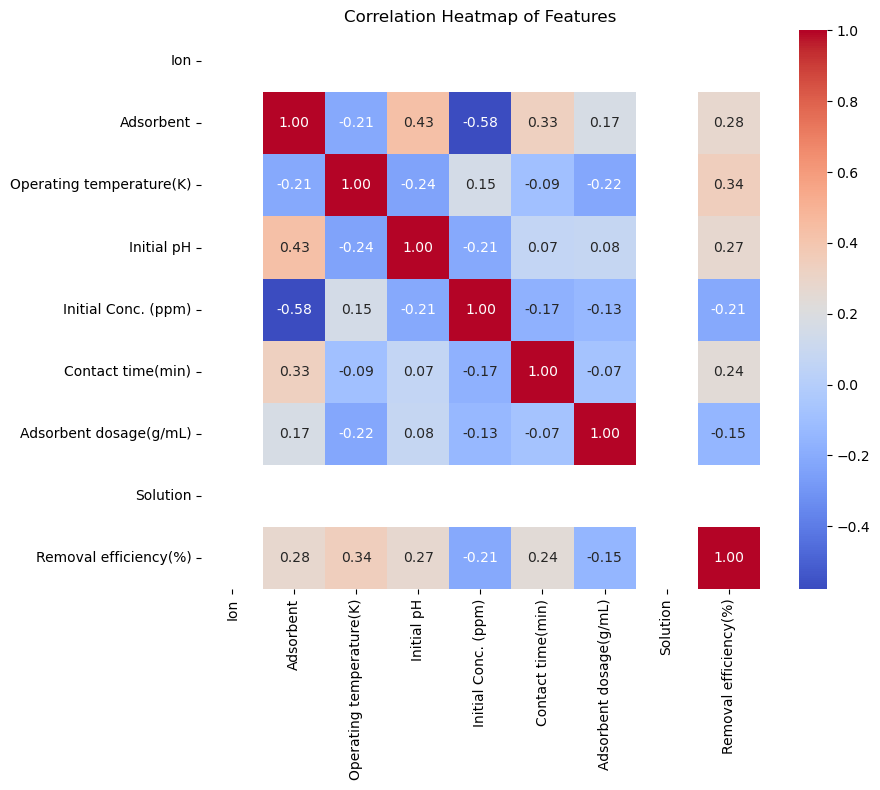

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot correlation heatmapE
corr.drop(columns=['Ion', 'Solution'], errors='ignore')
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title("Correlation Heatmap of Features")
plt.tight_layout()
plt.show()

In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.30, random_state=1)

In [31]:
print(X_train.shape,X_test.shape, Y_train.shape, Y_test.shape)

(349, 8) (150, 8) (349,) (150,)


In [32]:
X_train

,Ion,Adsorbent,Operating temperature(K),Initial pH,Initial Conc. (ppm),Contact time(min),Adsorbent dosage(g/mL),Solution
61,0,6,-0.264409,0.442849,0.797471,-0.271444,-0.661082,0
432,0,7,-0.264409,1.430799,-0.306506,2.784316,0.804719,0
39,0,6,-0.264409,0.442849,-0.676856,-0.271444,-0.661082,0
373,0,3,-1.141299,0.288482,0.170895,-0.271444,0.538210,0
230,0,0,-0.264409,0.144406,-0.306506,-0.271444,-0.261318,0
...,...,...,...,...,...,...,...,...
255,0,0,-0.264409,-0.586265,-0.373123,-0.271444,-0.048111,0
72,0,6,-0.264409,-1.903532,-0.306506,-0.271444,-0.661082,0
396,0,4,-1.141299,0.288482,0.679651,-0.271444,0.538210,0
235,0,0,-0.264409,2.326129,-0.306506,-0.271444,-0.261318,0


In [33]:
Y_train

61     0.634376
432    1.342619
39     1.090999
373   -2.406781
230   -1.370637
         ...   
255    0.248205
72     0.729726
396   -0.921430
235    0.108887
37     1.133907
Name: Removal efficiency(%), Length: 349, dtype: float64

In [34]:
X_test

,Ion,Adsorbent,Operating temperature(K),Initial pH,Initial Conc. (ppm),Contact time(min),Adsorbent dosage(g/mL),Solution
110,0,6,2.443426,0.442849,-0.306506,-0.271444,-0.661082,0
147,0,0,0.286277,-0.586265,-0.306506,-0.271444,-0.261318,0
307,0,0,-0.264409,-0.586265,1.657047,-0.271444,-0.687733,0
326,0,8,-0.264409,0.442849,-0.957258,-1.417354,4.535847,0
189,0,0,0.512515,-0.586265,1.804954,-0.271444,-0.261318,0
...,...,...,...,...,...,...,...,...
429,0,7,-0.264409,-0.236366,-0.306506,2.784316,0.804719,0
95,0,6,0.431841,0.442849,-0.306506,-0.271444,-0.661082,0
122,0,6,4.053395,0.442849,-0.306506,-0.271444,-0.661082,0
23,0,6,-0.264409,0.442849,-0.834371,-0.820462,-0.661082,0


In [35]:
Y_test

110    1.248858
147    0.045850
307   -0.296883
326   -0.503476
189   -0.300591
         ...   
429    1.259452
95     1.015249
122    1.298652
23     0.331372
13    -0.330255
Name: Removal efficiency(%), Length: 150, dtype: float64

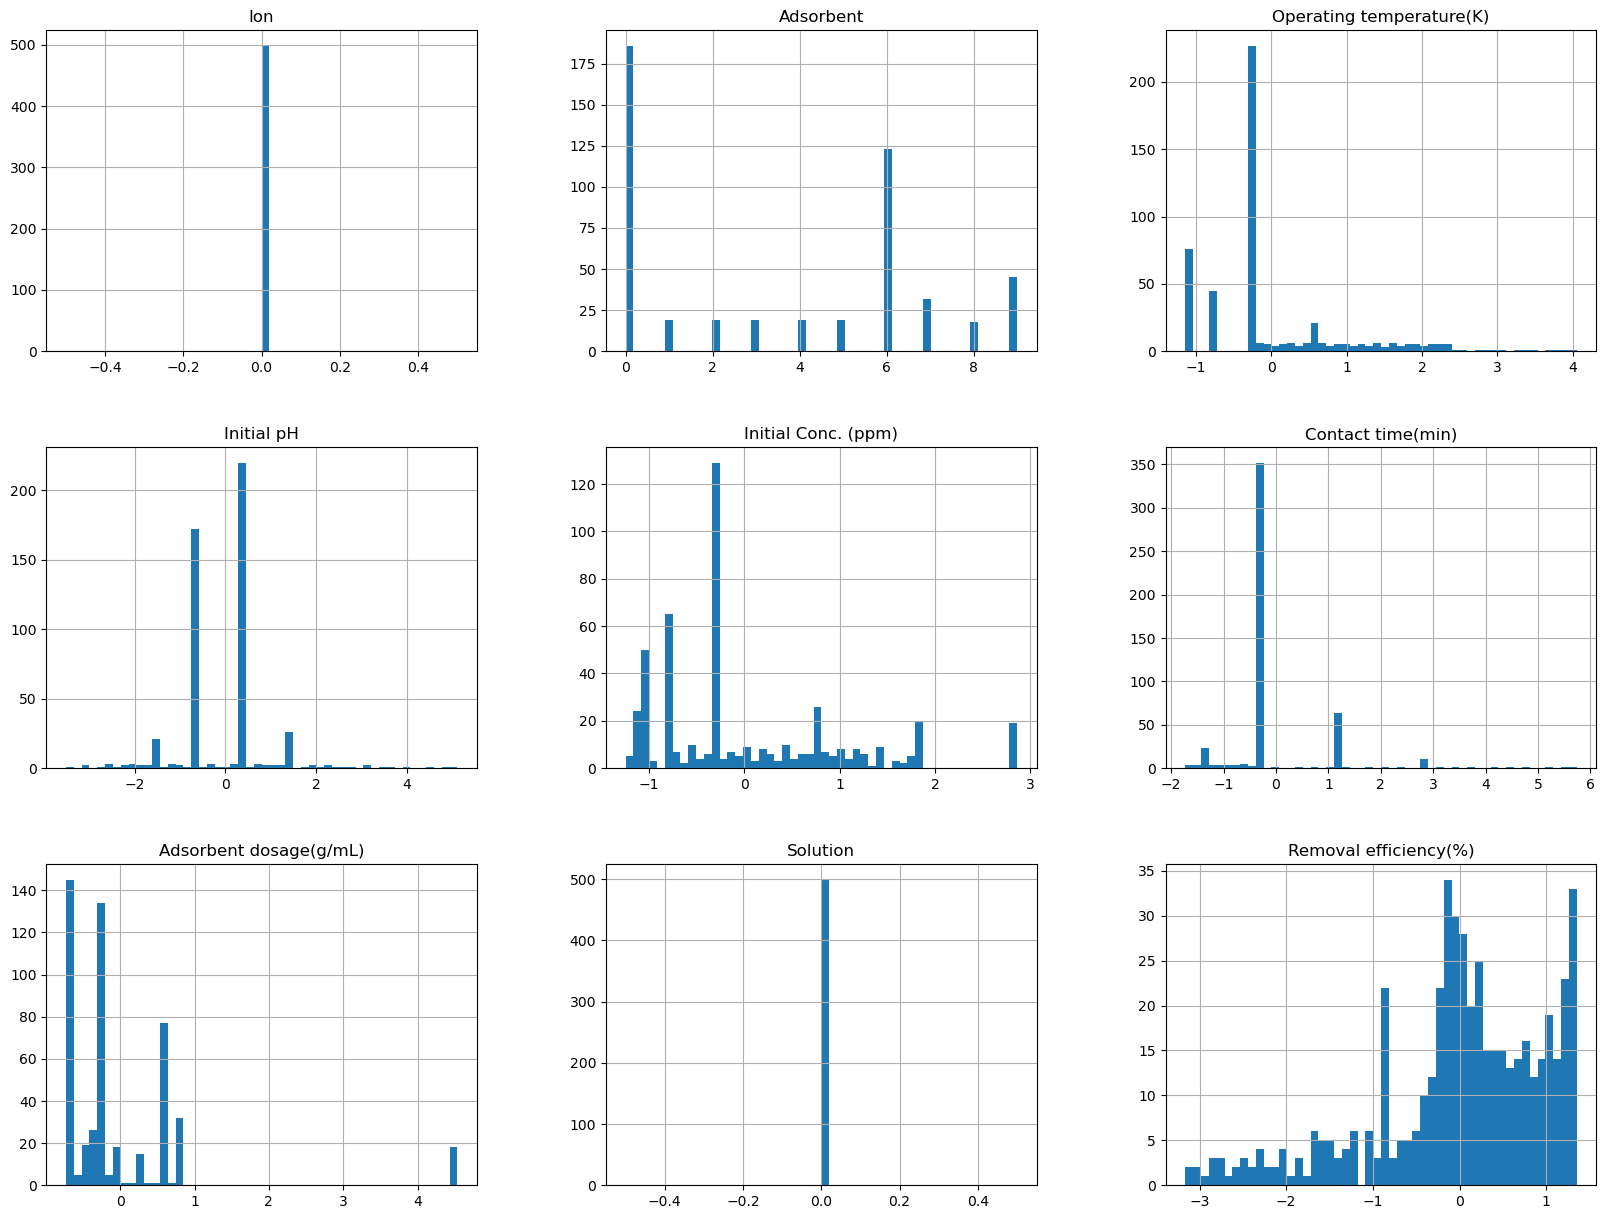

In [36]:
df.hist(bins = 50, figsize=(20,15))
plt.savefig('figrfr1.png')
plt.show()

# Model Training

In [37]:
model = RandomForestRegressor(random_state=seed)

In [38]:
model.fit(X_train, Y_train)
from sklearn.linear_model import LinearRegression
regr = LinearRegression()
regr.fit(X_train, Y_train)
print(regr.score(X_test, Y_test))

0.4096560544253688


In [39]:
# Decision tree regressor
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state = seed)
# fit the regressor with X and Y data
regressor.fit(X_train, Y_train)
print(regressor.score(X_test,Y_test))

0.9731525563768711


In [40]:
'''from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(solver='lbfgs', alpha=1e-5,
                    hidden_layer_sizes=(5, 2), random_state=1)
clf.fit(X_train, Y_train)
print(clf.score(X_test, Y_test))'''

"from sklearn.neural_network import MLPClassifier\nclf = MLPClassifier(solver='lbfgs', alpha=1e-5,\n                    hidden_layer_sizes=(5, 2), random_state=1)\nclf.fit(X_train, Y_train)\nprint(clf.score(X_test, Y_test))"

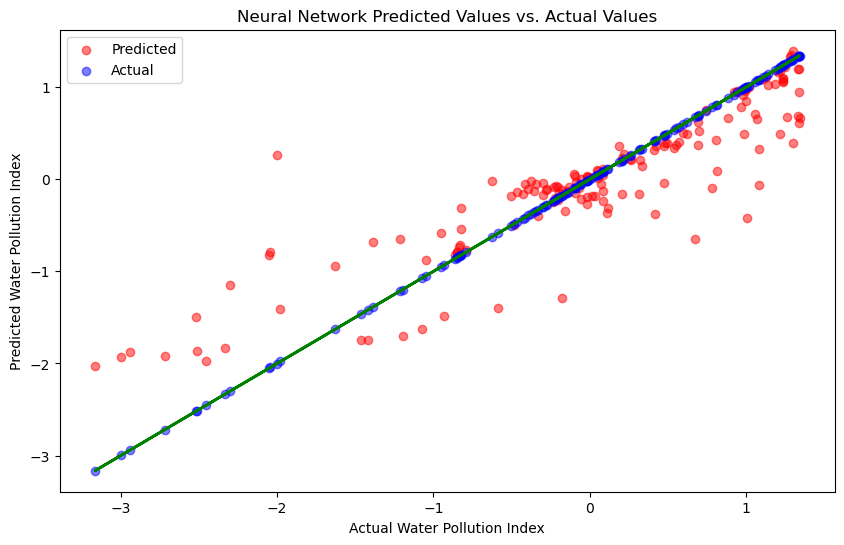

In [41]:
#Artfical neural network(ANNN)
from sklearn.neural_network import MLPRegressor
nn_model = MLPRegressor(
    hidden_layer_sizes=(10,),  # One hidden layer with 100 neurons
    activation='relu',          # 'relu' activation function
    solver='adam',              # 'adam' solver for weight optimization
    max_iter=500,               # Set the number of iterations (epochs)
    random_state=seed             # Set the seed for reproducibility
)
nn_model.fit(X_train, Y_train)

# Predicting the water pollution values using the air quality index from the test set
y_pred_nn = nn_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(Y_test, y_pred_nn, alpha=0.5, color='red', label='Predicted')
plt.scatter(Y_test, Y_test, alpha=0.5, color='blue', label='Actual')


plt.plot(Y_test,Y_test, color='green', linewidth=2)

plt.title('Neural Network Predicted Values vs. Actual Values')
plt.xlabel('Actual Water Pollution Index')
plt.ylabel('Predicted Water Pollution Index')
plt.legend()
plt.show()


In [53]:
Y_train_pred = model.predict(X_train)
Y_train_pred_nn = nn_model.predict(X_train)
Y_train_pred_dc = regressor.predict(X_train)

In [54]:
#ANN Score
print(nn_model.score(X_test,Y_test))

0.782389561146683


In [55]:
print(Y_train_pred)

[ 6.39736442e-01  1.33183295e+00  1.09388111e+00 -2.24362027e+00
 -1.23588019e+00  1.61897133e-01 -9.33300712e-01  1.05096801e+00
  4.56010937e-02  1.23441794e+00 -1.35250465e+00 -2.47938541e+00
  1.25658697e+00  8.53146496e-02  4.05528053e-02  2.83967185e-01
  9.35844253e-01 -1.24527223e+00 -1.24599860e-01  5.34834279e-01
  3.34238179e-01 -8.27190774e-01  7.61207904e-01 -1.70680722e-01
  1.03690196e-02  4.62892725e-01  3.23076853e-01  9.51850983e-01
  9.52297542e-01 -2.62180288e-01 -2.12721601e-03 -2.73455971e+00
  2.29521950e-01 -8.27507550e-01  5.74457664e-02  6.65957878e-01
  1.29048361e+00 -4.45746228e-01  9.96549260e-01 -2.48844266e+00
 -9.16270022e-01  1.31466560e+00 -2.05089431e+00  3.84371445e-01
 -8.51712848e-01 -3.99617691e-01 -1.11386840e+00  1.42519109e-02
  4.10719367e-02 -2.11178272e-01 -8.26901543e-01 -1.39103162e+00
 -1.24414456e-01  4.84934623e-01 -3.41173672e-02  3.78073003e-01
  2.11172242e-01  1.10831549e-01  1.80146192e-01 -2.24707473e-01
 -2.29655114e-01  1.31672

In [56]:
predictions1 = pd.DataFrame({'Y_train' : Y_train, 'Y_train_pred' : Y_train_pred})

In [57]:
predictions1

,Y_train,Y_train_pred
61,0.634376,0.639736
432,1.342619,1.331833
39,1.090999,1.093881
373,-2.406781,-2.243620
230,-1.370637,-1.235880
...,...,...
255,0.248205,0.250006
72,0.729726,0.727141
396,-0.921430,-0.925402
235,0.108887,0.070493


In [58]:
len(Y_train_pred)

349

In [64]:
print('The training r_sq is: %.4f'% model.score(X_train, Y_train))
print('The training r_sq is: %.4f'% nn_model.score(X_train, Y_train))
print('The training r_sq is: %.4f'% regressor.score(X_train, Y_train))

The training r_sq is: 0.9928
The training r_sq is: 0.7286
The training r_sq is: 1.0000


In [65]:
print('The MAE is: %.4f'% mean_absolute_error(Y_train, Y_train_pred))
print('The MAE is: %.4f'% mean_absolute_error(Y_train, Y_train_pred_nn))
print('The MAE is: %.4f'% mean_absolute_error(Y_train, Y_train_pred_dc))

The MAE is: 0.0389
The MAE is: 0.3365
The MAE is: 0.0000


In [66]:
print('The RMSE is: %.4f'% np.sqrt(mean_squared_error(Y_train, Y_train_pred)))
print('The RMSE is: %.4f'% np.sqrt(mean_squared_error(Y_train, Y_train_pred_nn)))
print('The RMSE is: %.4f'% np.sqrt(mean_squared_error(Y_train, Y_train_pred_dc)))

The RMSE is: 0.0828
The RMSE is: 0.5099
The RMSE is: 0.0000


In [67]:
print('The EVS is: %.4f'% explained_variance_score(Y_train, Y_train_pred))
print('The EVS is: %.4f'% explained_variance_score(Y_train, Y_train_pred_nn))
print('The EVS is: %.4f'% explained_variance_score(Y_train, Y_train_pred_dc))

The EVS is: 0.9929
The EVS is: 0.7286
The EVS is: 1.0000


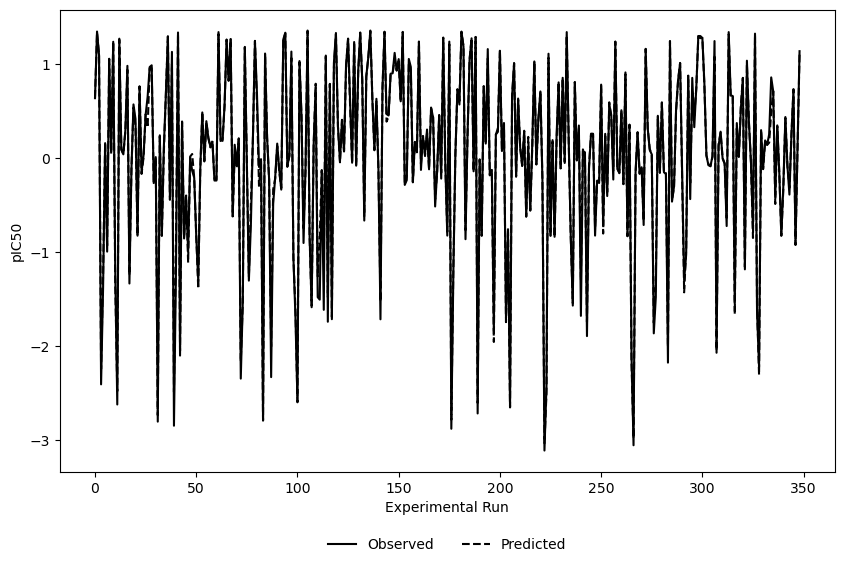

In [68]:
plt.rcParams['figure.figsize'] = 10,6
x_ax = range(len(X_train))
plt.plot(x_ax, Y_train, label = 'Observed', color = 'k', linestyle = '-')
plt.plot(x_ax, Y_train_pred, label = 'Predicted', color = 'k', linestyle = '--')
plt.ylabel('pIC50')
plt.xlabel('Experimental Run')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc = 'lower center', ncol = 2, frameon = False)

In [69]:
Y_test_pred = model.predict(X_test)
Y_test_pred_nn = nn_model.predict(X_test)
Y_test_pred_dc = regressor.predict(X_test)

In [70]:
Y_test_pred

array([ 1.24624089e+00,  3.72155317e-02, -2.88465291e-01, -1.10663829e-01,
       -2.51882416e-01,  5.17035369e-02, -1.38511988e+00, -5.87156575e-01,
        2.74728764e-01,  2.22402433e-01, -8.19489088e-01,  5.88209998e-01,
        7.62484544e-01,  8.07113309e-02, -2.11824538e-01, -4.22332340e-01,
        8.95065948e-01,  2.27551369e-01,  8.40015236e-01, -8.15702195e-02,
        7.80659442e-01, -2.88375237e-01, -8.78580667e-02, -1.80634273e-01,
        7.77571139e-01, -1.23700850e+00,  9.48127009e-01,  1.23920878e+00,
        4.16303326e-01,  6.25068330e-01,  5.52575332e-01, -6.45622430e-01,
       -8.33293746e-01,  3.96518061e-01,  1.48394418e-01, -6.56274160e-01,
       -1.41299406e+00,  3.45616046e-02,  9.09843714e-01, -9.57144325e-02,
       -6.11651752e-02,  1.07139359e-01,  5.52575332e-01, -2.15590889e-01,
        2.02039767e-01,  9.16715849e-01, -1.51367378e+00,  5.29182633e-01,
       -2.85140666e+00,  1.33842381e+00, -1.81439921e+00, -9.45505598e-01,
       -2.86502062e+00,  

In [71]:
len(Y_test_pred)

150

In [72]:
predictions2 = pd.DataFrame({'Y_test' : Y_test, 'Y_test_pred' : Y_test_pred})

In [73]:
predictions2

,Y_test,Y_test_pred
110,1.248858,1.246241
147,0.045850,0.037216
307,-0.296883,-0.288465
326,-0.503476,-0.110664
189,-0.300591,-0.251882
...,...,...
429,1.259452,1.222634
95,1.015249,1.022315
122,1.298652,1.292263
23,0.331372,0.303599


In [75]:
print('The testing r_sq is: %.4f'% model.score(X_test, Y_test))
print('The testing r_sq for MLP is: %.4f'% nn_model.score(X_test, Y_test))
print('The testing r_sq for Decision Tree is: %.4f'% regressor.score(X_test, Y_test))

The testing r_sq is: 0.9726
The testing r_sq for MLP is: 0.7824
The testing r_sq for Decision Tree is: 0.9732


In [76]:
print('The MAE is: %.4f'% mean_absolute_error(Y_test, Y_test_pred))
print('The MAE for MLP is: %.4f'% mean_absolute_error(Y_test, Y_test_pred_nn))
print('The MAE for Decision Tre is: %.4f'% mean_absolute_error(Y_test, Y_test_pred_dc))

The MAE is: 0.0934
The MAE for MLP is: 0.3229
The MAE for Decision Tre is: 0.0993


In [77]:
print('The RMSE is: %.4f'% np.sqrt(mean_squared_error(Y_test, Y_test_pred)))
print('The RMSE for MLP is: %.4f'% np.sqrt(mean_squared_error(Y_test, Y_test_pred_nn)))
print('The RMSE for Decision Tre is: %.4f'% np.sqrt(mean_squared_error(Y_test, Y_test_pred_dc)))

The RMSE is: 0.1735
The RMSE for MLP is: 0.4886
The RMSE for Decision Tre is: 0.1716


In [78]:
print('The EVS is: %.4f'% explained_variance_score(Y_test, Y_test_pred))
print('The EVS is for MLP: %.4f'% explained_variance_score(Y_test, Y_test_pred_nn))
print('The EVS is for Decision Tre: %.4f'% explained_variance_score(Y_test, Y_test_pred_dc))

The EVS is: 0.9726
The EVS is for MLP: 0.7829
The EVS is for Decision Tre: 0.9732


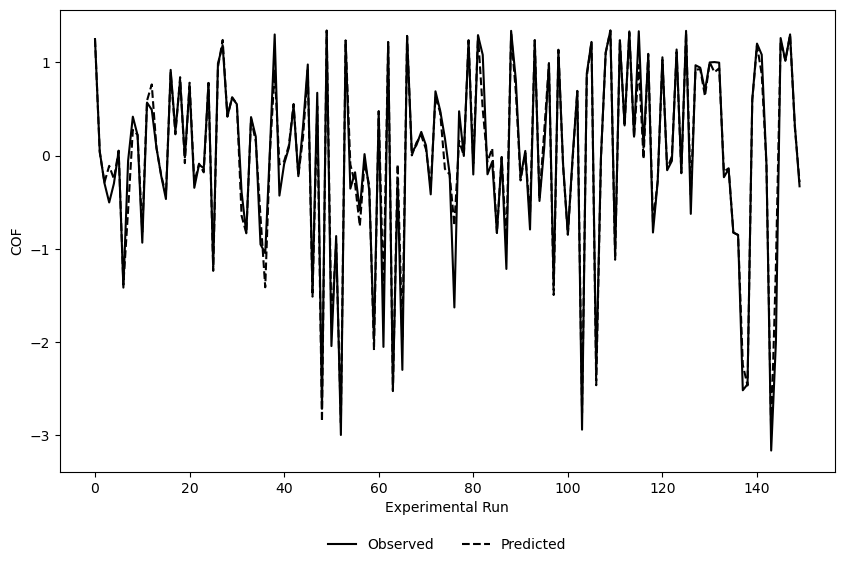

In [79]:
plt.rcParams['figure.figsize'] = 10,6
x_ax = range(len(X_test))
plt.plot(x_ax, Y_test, label = 'Observed', color = 'k', linestyle = '-')
plt.plot(x_ax, Y_test_pred, label = 'Predicted', color = 'k', linestyle = '--')
plt.ylabel('COF')
plt.xlabel('Experimental Run')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc = 'lower center', ncol = 2, frameon = False)

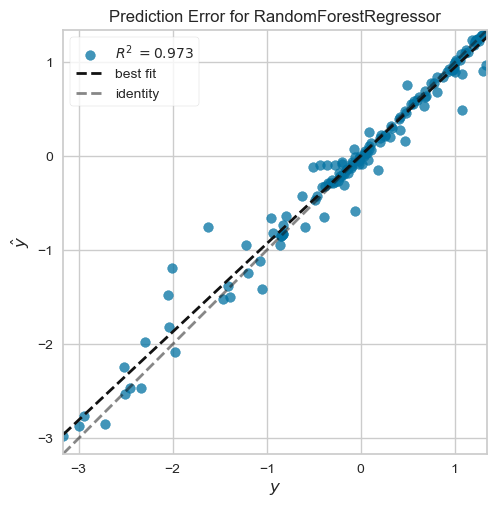

<Axes: title={'center': 'Prediction Error for RandomForestRegressor'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [80]:
from yellowbrick.regressor import PredictionError
visualizer = PredictionError(model)
visualizer.fit(X_train, Y_train)
visualizer.score(X_test, Y_test)
visualizer.poof()

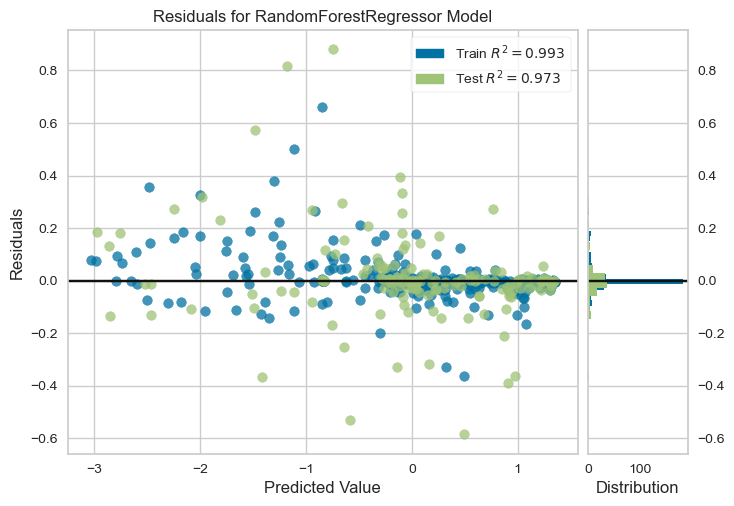

<Axes: title={'center': 'Residuals for RandomForestRegressor Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [81]:
from yellowbrick.regressor import ResidualsPlot
visualizer = ResidualsPlot(model)
visualizer.fit(X_train, Y_train)
visualizer.score(X_test, Y_test)
visualizer.poof()

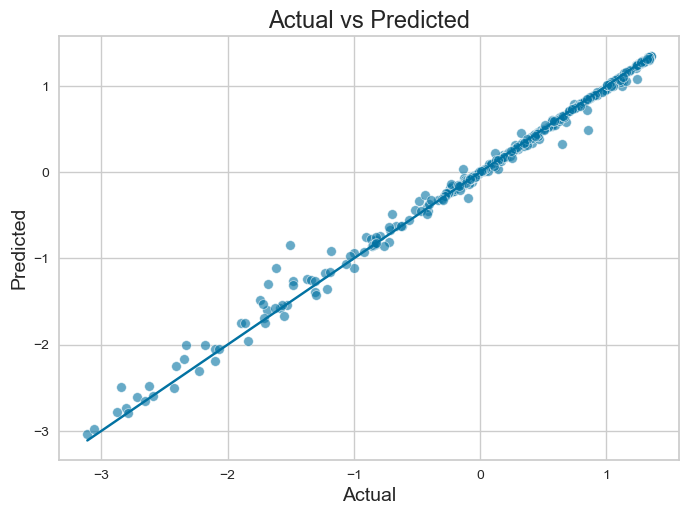

In [82]:
sns.scatterplot(x=Y_train, y=Y_train_pred, alpha=0.6)
sns.lineplot(x=Y_train, y=Y_train)
plt.xlabel('Actual', fontsize = 14)
plt.ylabel('Predicted', fontsize = 14)
plt.title('Actual vs Predicted', fontsize = 17)
plt.show()

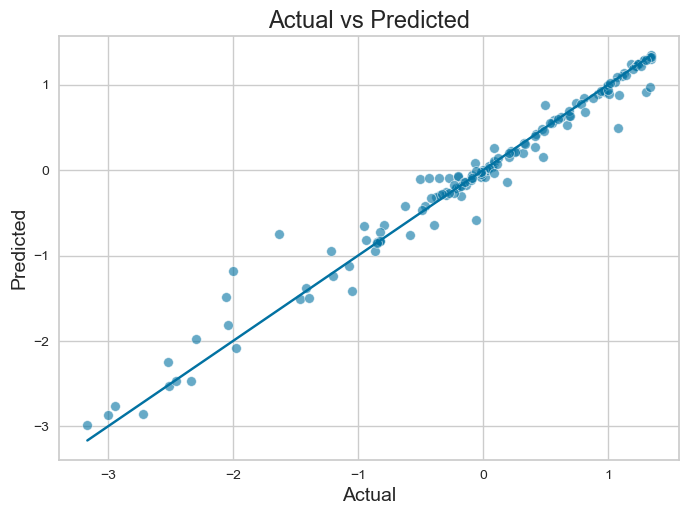

In [83]:
sns.scatterplot(x=Y_test, y=Y_test_pred, alpha=0.6)
sns.lineplot(x=Y_test, y=Y_test)
plt.xlabel('Actual', fontsize = 14)
plt.ylabel('Predicted', fontsize = 14)
plt.title('Actual vs Predicted', fontsize = 17)
plt.show()

In [84]:
model.score(X_test, Y_test)

0.9725527409444533

In [85]:
MSE_test = round(np.mean(np.square(Y_test - Y_test_pred)),2)
RMSE_test = round(np.sqrt(MSE_test),2)
RMSE_test

0.17

In [86]:
my_param_grid = {'n_estimators':[10, 100, 500], 'max_features':['sqrt', 'log2'], 'max_depth': [5,10,20]}

In [87]:
from sklearn.model_selection import GridSearchCV

In [88]:
GridSearchCV(estimator=RandomForestRegressor(random_state=seed), param_grid = my_param_grid, refit = True, verbose = 3, cv=5)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=1),
             param_grid={'max_depth': [5, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [10, 100, 500]},
             verbose=3)

In [89]:
grid = GridSearchCV(estimator=RandomForestRegressor(random_state=seed), param_grid = my_param_grid, refit = True, verbose = 3, cv=5)

In [90]:
grid.fit(X_train, Y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV 1/5] END max_depth=5, max_features=sqrt, n_estimators=10;, score=0.720 total time=   0.0s
[CV 2/5] END max_depth=5, max_features=sqrt, n_estimators=10;, score=0.652 total time=   0.0s
[CV 3/5] END max_depth=5, max_features=sqrt, n_estimators=10;, score=0.809 total time=   0.0s
[CV 4/5] END max_depth=5, max_features=sqrt, n_estimators=10;, score=0.820 total time=   0.0s
[CV 5/5] END max_depth=5, max_features=sqrt, n_estimators=10;, score=0.635 total time=   0.0s
[CV 1/5] END max_depth=5, max_features=sqrt, n_estimators=100;, score=0.733 total time=   0.0s
[CV 2/5] END max_depth=5, max_features=sqrt, n_estimators=100;, score=0.668 total time=   0.0s
[CV 3/5] END max_depth=5, max_features=sqrt, n_estimators=100;, score=0.819 total time=   0.0s
[CV 4/5] END max_depth=5, max_features=sqrt, n_estimators=100;, score=0.759 total time=   0.0s
[CV 5/5] END max_depth=5, max_features=sqrt, n_estimators=100;, score=0.688 total time=  

[CV 2/5] END max_depth=20, max_features=log2, n_estimators=500;, score=0.865 total time=   0.6s
[CV 3/5] END max_depth=20, max_features=log2, n_estimators=500;, score=0.976 total time=   0.6s
[CV 4/5] END max_depth=20, max_features=log2, n_estimators=500;, score=0.959 total time=   0.6s
[CV 5/5] END max_depth=20, max_features=log2, n_estimators=500;, score=0.884 total time=   0.6s


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=1),
             param_grid={'max_depth': [5, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [10, 100, 500]},
             verbose=3)

In [91]:
grid.best_params_

{'max_depth': 20, 'max_features': 'log2', 'n_estimators': 500}

In [92]:
Y_test_optimised = grid.predict(X_test)

In [93]:
Y_test_optimised

array([ 1.2444038 ,  0.02404072, -0.28020474, -0.09613175, -0.22023341,
        0.03865745, -1.56077066, -0.45848084,  0.23853926,  0.20256737,
       -1.07354884,  0.57893798,  0.80418033,  0.08748229, -0.18256142,
       -0.37039377,  0.91086061,  0.22548872,  0.83616413, -0.08926784,
        0.77892406, -0.27625687, -0.04335685, -0.17556215,  0.57656026,
       -1.37103235,  0.95128735,  1.23171337,  0.39955021,  0.62580813,
        0.5421644 , -0.5269066 , -0.83038756,  0.38865523,  0.11631421,
       -0.79654252, -1.36405798,  0.05616213,  0.96576688, -0.08758928,
       -0.0534495 ,  0.10232659,  0.5403877 , -0.21068245,  0.17398336,
        0.94648963, -1.71292914,  0.30581022, -2.76317444,  1.33871727,
       -1.63339503, -0.93443433, -2.85817974,  1.23417077, -0.08758928,
       -0.52155319, -0.98922282, -0.0569885 , -0.29675021, -1.75753631,
        0.43262736, -1.53634478,  1.21401978, -2.42416995, -0.08758928,
       -1.91904976,  1.28202494,  0.02451482,  0.10645072,  0.19

In [94]:
predictions2['Y_test_optimised'] = Y_test_optimised
predictions2.head()

,Y_test,Y_test_pred,Y_test_optimised
110,1.248858,1.246241,1.244404
147,0.045850,0.037216,0.024041
307,-0.296883,-0.288465,-0.280205
326,-0.503476,-0.110664,-0.096132
189,-0.300591,-0.251882,-0.220233


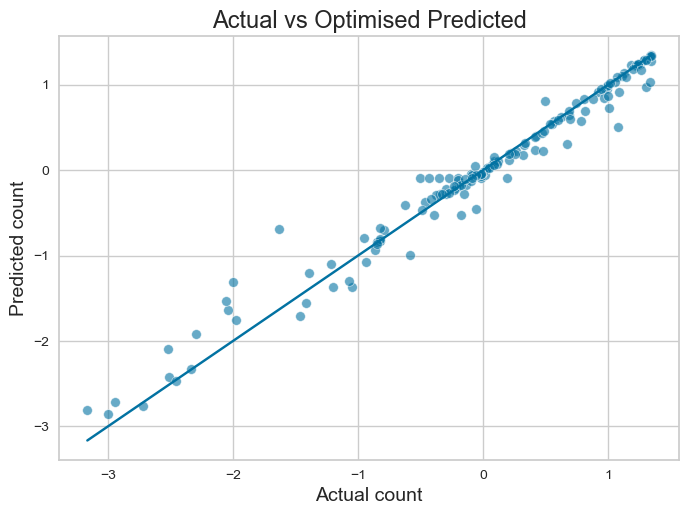

In [95]:
sns.scatterplot(x=Y_test, y=Y_test_optimised, alpha=0.6)
sns.lineplot(x=Y_test, y=Y_test)
plt.xlabel('Actual count', fontsize = 14)
plt.ylabel('Predicted count', fontsize = 14)
plt.title('Actual vs Optimised Predicted', fontsize = 17)
plt.show()

In [96]:
grid.score(X_test, Y_test)

0.9696558836745524

In [97]:
MSE_test = round(np.mean(np.square(Y_test - Y_test_optimised)),2)
RMSE_test = round(np.sqrt(MSE_test),2)
RMSE_test

0.17

In [98]:
print('The testing r_sq is: %.4f'% model.score(X_test, Y_test_optimised))

The testing r_sq is: 0.9935


In [99]:
print('The MAE is: %.4f'% mean_absolute_error(Y_test, Y_test_optimised))

The MAE is: 0.1062


In [100]:
print('The RMSE is: %.4f'% np.sqrt(mean_squared_error(Y_test, Y_test_optimised)))

The RMSE is: 0.1824


In [101]:
print('The EVS is: %.4f'% explained_variance_score(Y_test, Y_test_optimised))

The EVS is: 0.9697


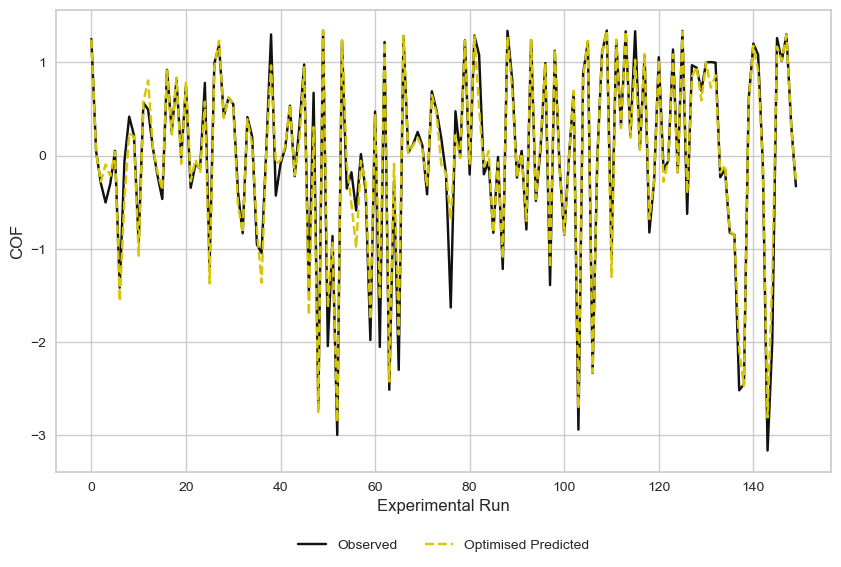

In [102]:
plt.rcParams['figure.figsize'] = 10,6
x_ax = range(len(X_test))
plt.plot(x_ax, Y_test, label = 'Observed', color = 'k', linestyle = '-')
plt.plot(x_ax, Y_test_optimised, label = 'Optimised Predicted', color = 'y', linestyle = '--')
plt.ylabel('COF')
plt.xlabel('Experimental Run')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc = 'lower center', ncol = 2, frameon = False)

In [103]:
Y_train_optimised = grid.predict(X_train)

In [104]:
Y_train_optimised

array([ 6.38818200e-01,  1.28577752e+00,  1.09790685e+00, -2.20948049e+00,
       -1.23089801e+00,  1.55329590e-01, -9.50257240e-01,  1.05241328e+00,
        5.35289726e-02,  1.23467157e+00, -1.21323652e+00, -2.50190830e+00,
        1.25410563e+00,  9.12246963e-02,  2.55626198e-02,  2.70959446e-01,
        9.56214071e-01, -1.25755657e+00, -1.46636460e-01,  5.46218302e-01,
        4.58675047e-01, -8.27094152e-01,  7.23357289e-01, -1.91761908e-01,
        1.84710723e-02,  4.51827809e-01,  3.86019952e-01,  8.65049026e-01,
        9.68872314e-01, -2.59790165e-01, -1.12232584e-03, -2.68311590e+00,
        2.26248243e-01, -8.29380237e-01, -8.03789836e-03,  6.65004674e-01,
        1.29054823e+00, -4.39696758e-01,  9.76606137e-01, -2.49087336e+00,
       -9.35219379e-01,  1.32797655e+00, -2.03935720e+00,  3.83083151e-01,
       -8.49208939e-01, -3.87600327e-01, -9.99390383e-01,  5.52202698e-03,
       -4.20180182e-02, -2.06698909e-01, -8.26899636e-01, -1.45061308e+00,
       -1.25248951e-01,  

In [105]:
predictions1['Y_train_optimised'] = Y_train_optimised
predictions1.head()

,Y_train,Y_train_pred,Y_train_optimised
61,0.634376,0.639736,0.638818
432,1.342619,1.331833,1.285778
39,1.090999,1.093881,1.097907
373,-2.406781,-2.243620,-2.209480
230,-1.370637,-1.235880,-1.230898


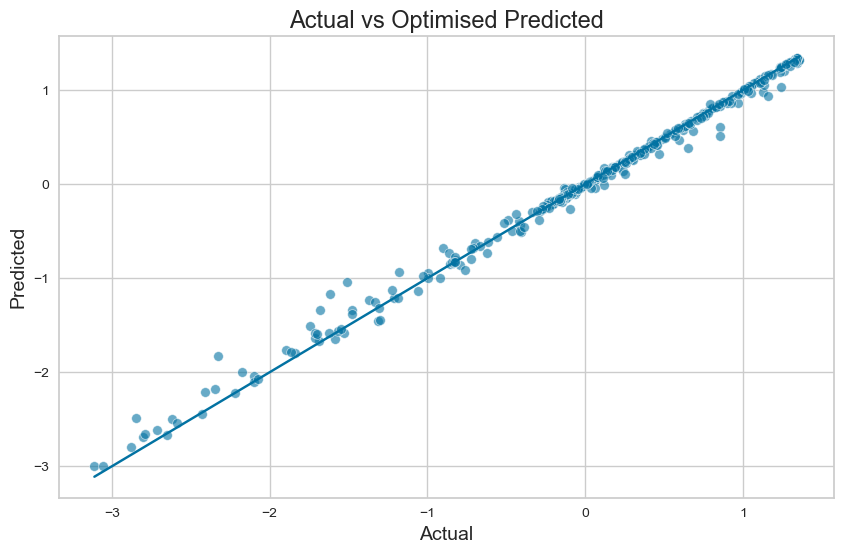

In [106]:
sns.scatterplot(x=Y_train, y=Y_train_optimised, alpha=0.6)
sns.lineplot(x=Y_train, y=Y_train)
plt.xlabel('Actual', fontsize = 14)
plt.ylabel('Predicted', fontsize = 14)
plt.title('Actual vs Optimised Predicted', fontsize = 17)
plt.show()

In [107]:
print('The training r_sq is: %.4f'% model.score(X_train, Y_train_optimised))

The training r_sq is: 0.9982


In [108]:
print('The MAE is: %.4f'% mean_absolute_error(Y_train, Y_train_optimised))

The MAE is: 0.0402


In [109]:
print('The RMSE is: %.4f'% np.sqrt(mean_squared_error(Y_train, Y_train_optimised)))

The RMSE is: 0.0800


In [110]:
print('The EVS is: %.4f'% explained_variance_score(Y_train, Y_train_optimised))

The EVS is: 0.9933


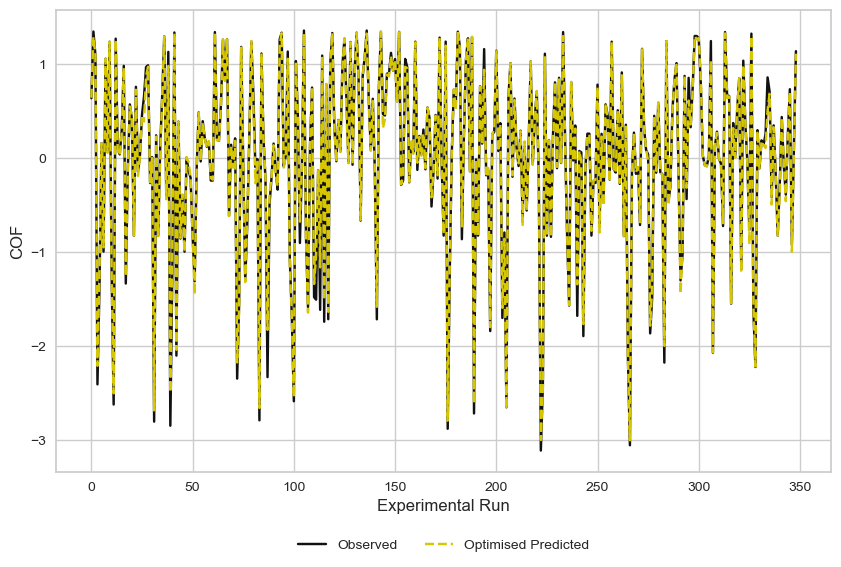

In [111]:
plt.rcParams['figure.figsize'] = 10,6
x_ax = range(len(X_train))
plt.plot(x_ax, Y_train, label = 'Observed', color = 'k', linestyle = '-')
plt.plot(x_ax, Y_train_optimised, label = 'Optimised Predicted', color = 'y', linestyle = '--')
plt.ylabel('COF')
plt.xlabel('Experimental Run')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc = 'lower center', ncol = 2, frameon = False)

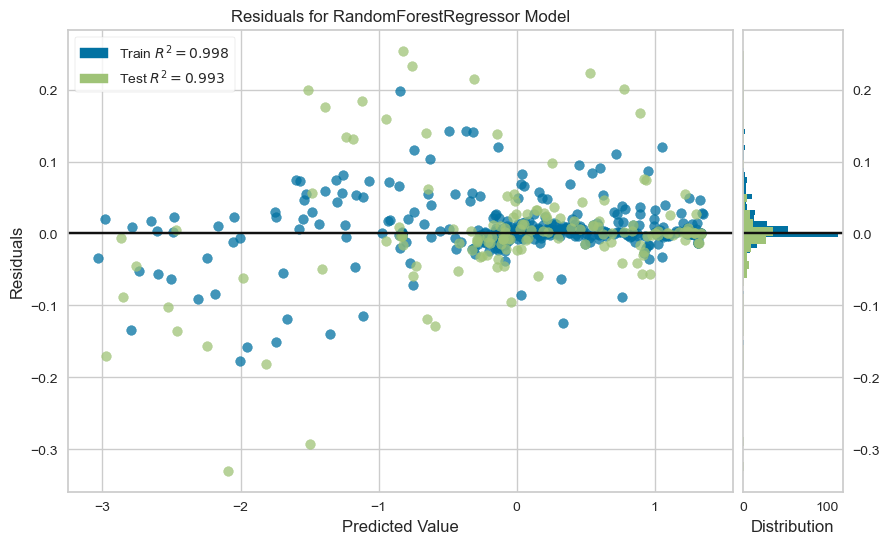

<Axes: title={'center': 'Residuals for RandomForestRegressor Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [112]:
from yellowbrick.regressor import ResidualsPlot
visualizer = ResidualsPlot(model)
visualizer.fit(X_train, Y_train_optimised)
visualizer.score(X_test, Y_test_optimised)
visualizer.poof()

In [113]:
features = list(X_train.columns)

In [114]:
features

['Ion',
 'Adsorbent',
 'Operating temperature(K)',
 'Initial pH',
 'Initial Conc. (ppm)',
 'Contact time(min)',
 'Adsorbent dosage(g/mL)',
 'Solution']

In [115]:
RFR = RandomForestRegressor(random_state=seed, n_estimators = 100, max_features='sqrt', max_depth=10)

In [116]:
RFR.fit(X_train, Y_train)

RandomForestRegressor(max_depth=10, max_features='sqrt', random_state=1)

In [117]:
importance = RFR.feature_importances_
importance

array([0.        , 0.21575175, 0.15143689, 0.1780094 , 0.19307538,
       0.13204868, 0.12967791, 0.        ])

In [118]:
FIM = pd.DataFrame({'features' : features, 'feature_importances' : importance})
FIM

,features,feature_importances
0,Ion,0.000000
1,Adsorbent,0.215752
2,Operating temperature(K),0.151437
3,Initial pH,0.178009
4,Initial Conc. (ppm),0.193075
5,Contact time(min),0.132049
6,Adsorbent dosage(g/mL),0.129678
7,Solution,0.000000


<Figure size 8000x4800 with 0 Axes>

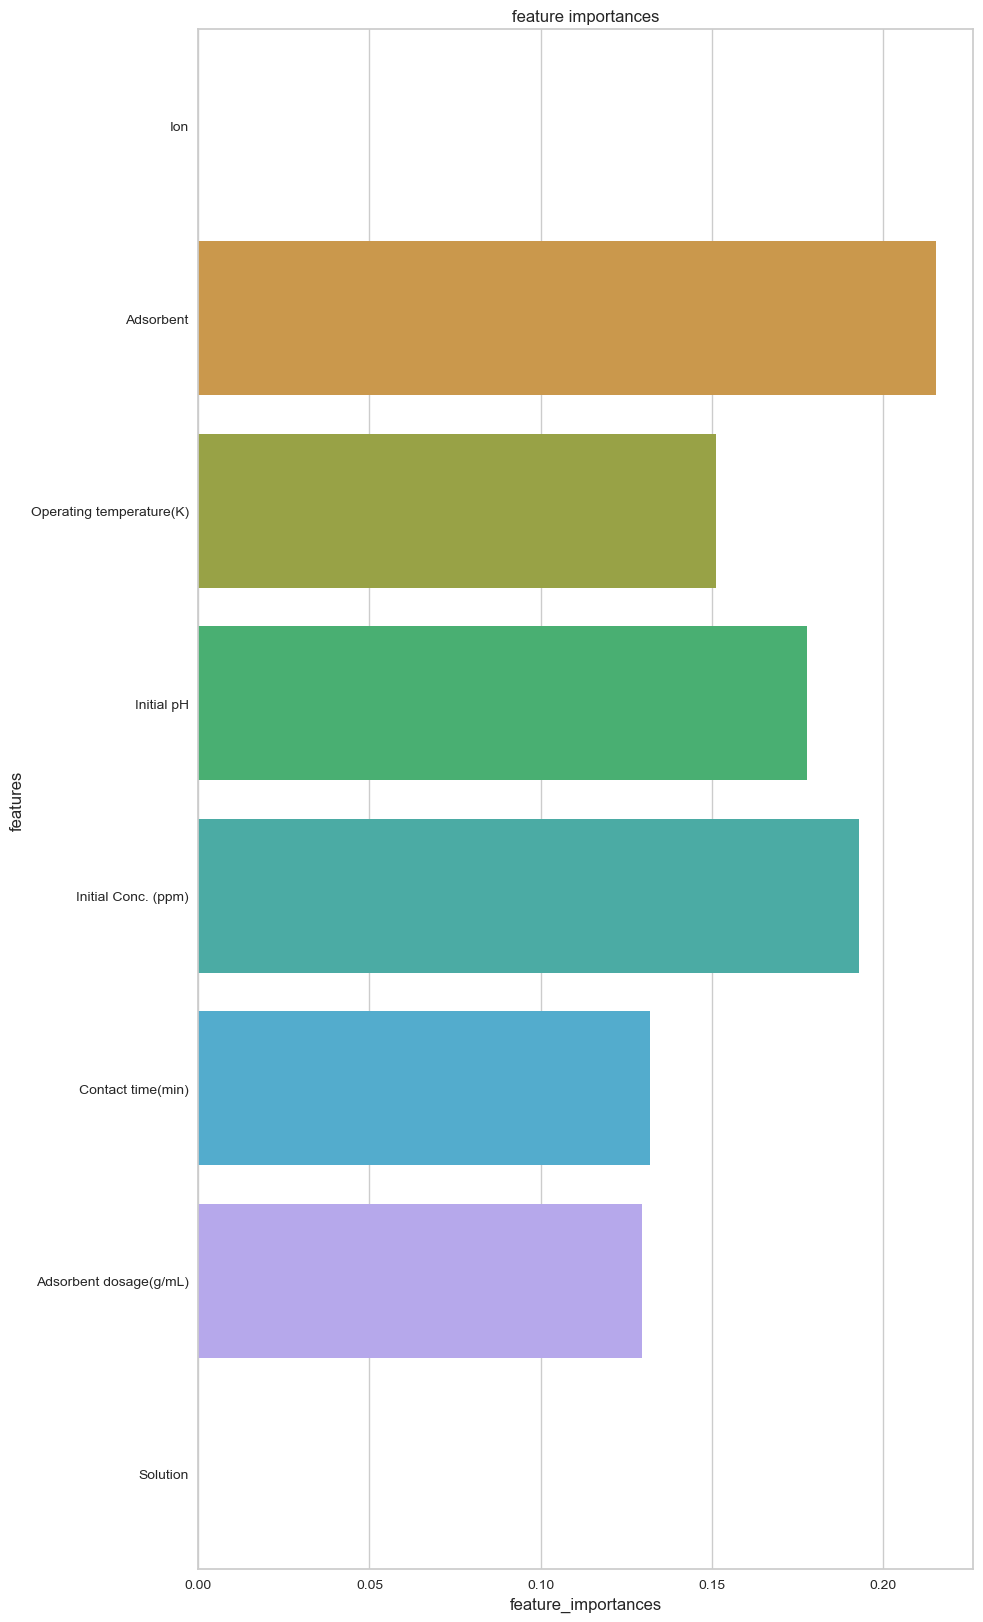

In [119]:
fig = plt.figure(dpi=800)
plt.figure(figsize=(10,20))
plt.title('feature importances')
sns.barplot(y='features', x='feature_importances', data=FIM)
plt.savefig('figrfr2.png')

plt.show()